In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
swiggy_analysis=pd.read_csv("/content/Swiggy chennai dataset.csv")

In [ ]:
swiggy_analysis.head()

,city,subcity,restaurant,rating,rating count,cost,cuisine,menu,item,price,veg_or_non_veg
0,Chennai,Poonamallee,LASSI AND SOUP CORNER,4.1,Too Few Ratings,200,Juices,Falooda,Regular Falooda,100.0,Veg
1,Chennai,Poonamallee,LASSI AND SOUP CORNER,4.1,Too Few Ratings,200,Juices,Falooda,Vanilla Falooda,110.0,Veg
2,Chennai,Poonamallee,LASSI AND SOUP CORNER,4.1,Too Few Ratings,200,Juices,Falooda,Strawberry Falooda,110.0,Veg
3,Chennai,Poonamallee,LASSI AND SOUP CORNER,4.1,Too Few Ratings,200,Juices,Falooda,Chocolate Falooda,130.0,Veg
4,Chennai,Poonamallee,LASSI AND SOUP CORNER,4.1,Too Few Ratings,200,Juices,Falooda,Butterscotch Falooda,130.0,Veg


In [ ]:
print(swiggy_analysis.sum().isnull())

city              False
subcity           False
restaurant        False
rating            False
rating count      False
cost              False
cuisine           False
menu              False
item              False
price             False
veg_or_non_veg    False
dtype: bool


In [ ]:
swiggy_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162520 entries, 0 to 162519
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   city            162520 non-null  object 
 1   subcity         162520 non-null  object 
 2   restaurant      162520 non-null  object 
 3   rating          162520 non-null  float64
 4   rating count    162520 non-null  object 
 5   cost            162520 non-null  int64  
 6   cuisine         162520 non-null  object 
 7   menu            162520 non-null  object 
 8   item            162520 non-null  object 
 9   price           4949 non-null    float64
 10  veg_or_non_veg  162520 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 13.6+ MB


In [ ]:
swiggy_analysis["price"].isnull().sum()

np.int64(157571)

In [ ]:
swiggy_analysis.count()

,0
city,162520
subcity,162520
restaurant,162520
rating,162520
rating count,162520
cost,162520
cuisine,162520
menu,162520
item,162520
price,4949


In [ ]:
swiggy_analysis.shape

(162520, 11)

In [ ]:
swiggy_analysis.describe()

,rating,cost,price
count,162520.000000,162520.000000,4949.000000
mean,4.040952,311.845416,181.816316
std,0.297419,180.921978,135.791572
min,1.600000,30.000000,4.500000
25%,4.000000,200.000000,90.000000
50%,4.100000,300.000000,156.000000
75%,4.100000,350.000000,230.000000
max,5.000000,2500.000000,1499.000000


In [ ]:
swiggy_analysis.drop(columns=['price']).inplace=True

In [ ]:
swiggy_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162520 entries, 0 to 162519
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   city            162520 non-null  object 
 1   subcity         162520 non-null  object 
 2   restaurant      162520 non-null  object 
 3   rating          162520 non-null  float64
 4   rating count    162520 non-null  object 
 5   cost            162520 non-null  int64  
 6   cuisine         162520 non-null  object 
 7   menu            162520 non-null  object 
 8   item            162520 non-null  object 
 9   price           4949 non-null    float64
 10  veg_or_non_veg  162520 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 13.6+ MB


In [ ]:
swiggy_analysis['rating count'] = swiggy_analysis['rating count'].astype(str).str.replace('rating count', 'Rating_Count')

In [ ]:
# Define the mapping for renaming columns
column_renames = {
    'city': 'City',
    'subcity': 'Sub_City',
    'restaurant': 'Restaurant',
    'rating': 'Rating',
    'rating count': 'Rating_Count',
    'cost': 'Cost',
    'cuisine': 'Cuisine',
    'menu': 'Menu',
    'item': 'Item',
    'price': 'Price',
    'veg_or_non_veg': 'Veg_or_Non_Veg'
}

# Rename the columns using the .rename() method
swiggy_analysis.rename(columns=column_renames, inplace=True)

In [ ]:
swiggy_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162520 entries, 0 to 162519
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   City            162520 non-null  object 
 1   Sub_City        162520 non-null  object 
 2   Restaurant      162520 non-null  object 
 3   Rating          162520 non-null  float64
 4   Rating_Count    162520 non-null  object 
 5   Cost            162520 non-null  int64  
 6   Cuisine         162520 non-null  object 
 7   Menu            162520 non-null  object 
 8   Item            162520 non-null  object 
 9   Price           4949 non-null    float64
 10  Veg_or_Non_Veg  162520 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 13.6+ MB


In [ ]:
# The error was due to the lambda function not accepting an argument
# when used with DataFrame.apply().
# Also, it's more robust to clean a specific column directly rather
# than using apply on the entire DataFrame.

# Ensure 'Rating_Count' column is treated as string for string operations
swiggy_analysis['Rating_Count'] = swiggy_analysis['Rating_Count'].astype(str)

# Replace 'Too Few Ratings' with '0' to enable numeric conversion, or with np.nan if preferred.
# The 'Rating_Count' column often contains 'Too Few Ratings' as seen in head() output.
swiggy_analysis['Rating_Count'] = swiggy_analysis['Rating_Count'].str.replace('Too Few Ratings', '0', regex=False)

# Remove commas from the rating count strings
swiggy_analysis['Rating_Count'] = swiggy_analysis['Rating_Count'].str.replace(',', '', regex=False)

# Convert the cleaned 'Rating_Count' column to a numeric type
# Use errors='coerce' to turn any remaining non-numeric values into NaN
swiggy_analysis['Rating_Count'] = pd.to_numeric(swiggy_analysis['Rating_Count'], errors='coerce')

In [ ]:
swiggy_analysis['Rating_Count'].isnull().sum()

np.int64(95346)

0.0


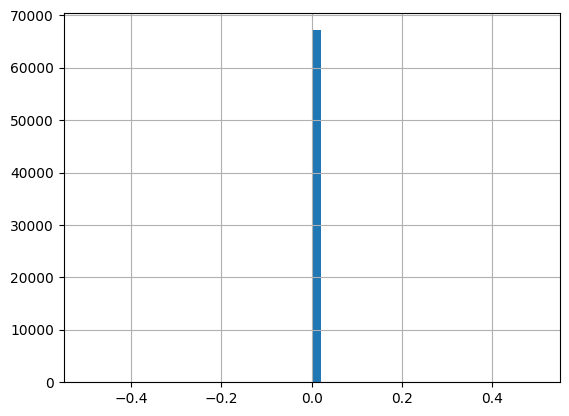

In [ ]:
print(swiggy_analysis['Rating_Count'].skew())
swiggy_analysis['Rating_Count'].hist(bins=50)
plt.show()

In [ ]:
swiggy_analysis['Rating_Count'] = (
    swiggy_analysis['Rating_Count']
    .astype(str)                # force to string
    .str.replace(',', '')       # remove commas
    .replace('nan', None)       # handle string 'nan'
    .astype(float)              # convert to numeric
)

Skewness: 0.0


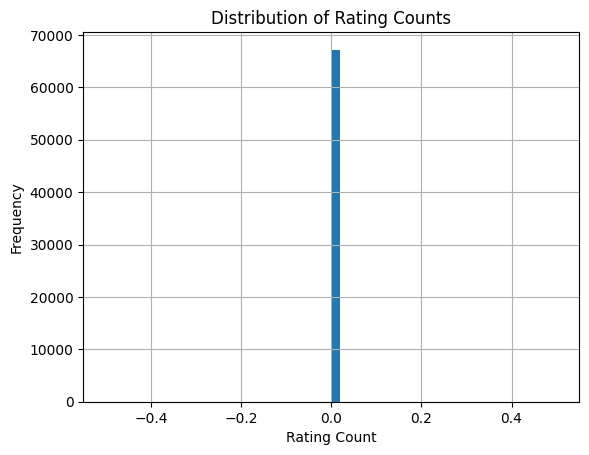

In [ ]:
print("Skewness:", swiggy_analysis['Rating_Count'].skew())

# Plot histogram
swiggy_analysis['Rating_Count'].dropna().hist(bins=50)
plt.xlabel("Rating Count")
plt.ylabel("Frequency")
plt.title("Distribution of Rating Counts")
plt.show()

In [ ]:
swiggy_analysis = swiggy_analysis.fillna(swiggy_analysis.median(numeric_only=True))

In [ ]:
# Define the mapping for renaming columns
column_renames = {
    'city': 'City',
    'subcity': 'Sub_City',
    'restaurant': 'Restaurant',
    'rating': 'Rating',
    'rating count': 'Rating_Count',
    'cost': 'Cost',
    'cuisine': 'Cuisine',
    'menu': 'Menu',
    'item': 'Item',
    'price': 'Price',
    'veg_or_non_veg': 'Veg_or_Non_Veg'
}

# Rename the columns using the .rename() method
swiggy_analysis.rename(columns=column_renames, inplace=True)
print("Columns renamed successfully.")

Columns renamed successfully.


In [ ]:
# Correctly drop the 'Price' column, checking if it exists first
if 'Price' in swiggy_analysis.columns:
    swiggy_analysis.drop(columns=['Price'], inplace=True)
    print("Price column dropped successfully.")
else:
    print("Price column not found in DataFrame, skipping drop operation.")

Price column dropped successfully.


In [ ]:
# Cleaning and converting 'Rating_Count' column to numeric
# Ensure 'Rating_Count' column is treated as string for string operations
swiggy_analysis['Rating_Count'] = swiggy_analysis['Rating_Count'].astype(str)

# Replace 'Too Few Ratings' with a value that will become NaN (e.g., empty string or None)
# and then convert to numeric
swiggy_analysis['Rating_Count'] = swiggy_analysis['Rating_Count'].str.replace('Too Few Ratings', '0', regex=False)

# Remove commas from the rating count strings
swiggy_analysis['Rating_Count'] = swiggy_analysis['Rating_Count'].str.replace(',', '', regex=False)

# Convert the cleaned 'Rating_Count' column to a numeric type
# Use errors='coerce' to turn any remaining non-numeric values into NaN
swiggy_analysis['Rating_Count'] = pd.to_numeric(swiggy_analysis['Rating_Count'], errors='coerce')

print("Rating_Count column cleaned and converted to numeric.")
print(f"Number of NaNs in Rating_Count after cleaning: {swiggy_analysis['Rating_Count'].isnull().sum()}")
print("First 5 rows of Rating_Count:")
print(swiggy_analysis['Rating_Count'].head())

Rating_Count column cleaned and converted to numeric.
Number of NaNs in Rating_Count after cleaning: 0
First 5 rows of Rating_Count:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Rating_Count, dtype: float64


In [ ]:
print("Unique Value Counts for Categorical Columns:")
for column in ['City', 'Sub_City', 'Restaurant', 'Cuisine', 'Menu', 'Item', 'Veg_or_Non_Veg']:
    if column in swiggy_analysis.columns:
        print(f"{column}: {swiggy_analysis[column].nunique()} unique values")
    else:
        print(f"Column '{column}' not found in DataFrame.")

Unique Value Counts for Categorical Columns:
City: 1 unique values
Sub_City: 38 unique values
Restaurant: 5303 unique values
Cuisine: 643 unique values
Menu: 174 unique values
Item: 58194 unique values
Veg_or_Non_Veg: 2 unique values


In [ ]:
swiggy_analysis['Rating_Count'].isnull().sum()

np.int64(0)

In [ ]:
swiggy_analysis['Rating_Count'] = swiggy_analysis['Rating_Count'].fillna(swiggy_analysis['Rating_Count'].median())

In [ ]:
print("Current DataFrame Columns:")
print(swiggy_analysis.columns)
print("\nDataFrame Info:")
swiggy_analysis.info()

Current DataFrame Columns:
Index(['City', 'Sub_City', 'Restaurant', 'Rating', 'Rating_Count', 'Cost',
       'Cuisine', 'Menu', 'Item', 'Veg_or_Non_Veg'],
      dtype='object')

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162520 entries, 0 to 162519
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   City            162520 non-null  object 
 1   Sub_City        162520 non-null  object 
 2   Restaurant      162520 non-null  object 
 3   Rating          162520 non-null  float64
 4   Rating_Count    162520 non-null  float64
 5   Cost            162520 non-null  int64  
 6   Cuisine         162520 non-null  object 
 7   Menu            162520 non-null  object 
 8   Item            162520 non-null  object 
 9   Veg_or_Non_Veg  162520 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 12.4+ MB


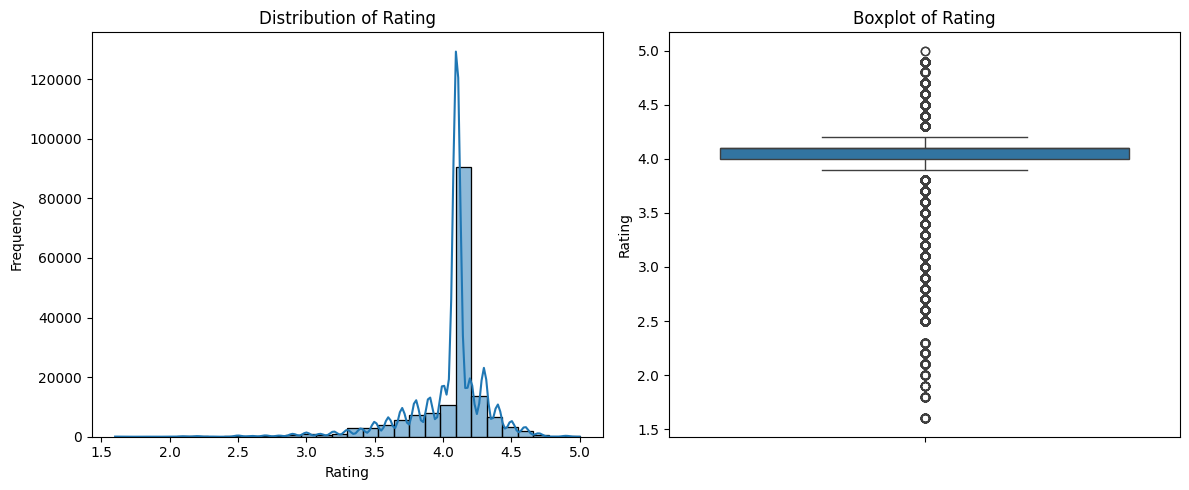

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure for Rating
plt.figure(figsize=(12, 5))

# Histogram for Rating
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(swiggy_analysis['Rating'], kde=True, bins=30)
plt.title('Distribution of Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')

# Boxplot for Rating
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=swiggy_analysis['Rating'])
plt.title('Boxplot of Rating')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

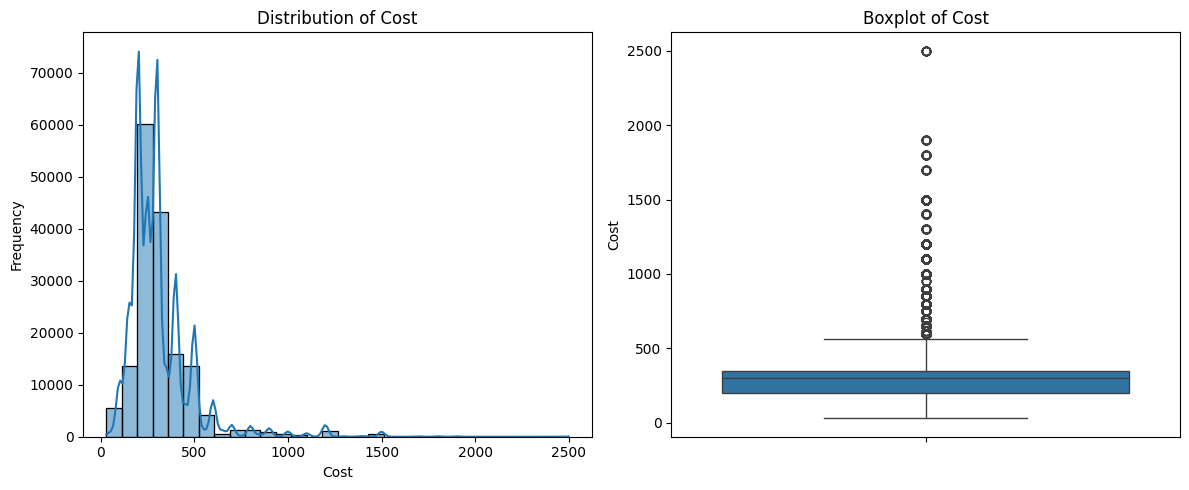

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure for Cost
plt.figure(figsize=(12, 5))

# Histogram for Cost
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(swiggy_analysis['Cost'], kde=True, bins=30)
plt.title('Distribution of Cost')
plt.xlabel('Cost')
plt.ylabel('Frequency')

# Boxplot for Cost
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=swiggy_analysis['Cost'])
plt.title('Boxplot of Cost')
plt.ylabel('Cost')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate restaurant count per subcity
subcity_restaurant_counts = swiggy_analysis['Sub_City'].value_counts().reset_index()
subcity_restaurant_counts.columns = ['Sub_City', 'Restaurant_Count']

# Get the top 10 subcities by restaurant count
top_10_subcities = subcity_restaurant_counts.head(10)

# Now, identify the subcity with the highest number of restaurants from the top_10_subcities
if not top_10_subcities.empty:
    highest_restaurant_subcity = top_10_subcities.iloc[0]['Sub_City']
    highest_restaurant_count = top_10_subcities.iloc[0]['Restaurant_Count']
    print(f"The subcity with the highest number of restaurants is '{highest_restaurant_subcity}' with {int(highest_restaurant_count)} restaurants.")
else:
    print("No subcities found or data not processed correctly.")

# Optionally, you can also display the chart again if needed
# plt.figure(figsize=(12, 7))
# sns.barplot(x='Restaurant_Count', y='Sub_City', data=top_10_subcities, palette='viridis')
# plt.title('Top 10 Subcities by Restaurant Count')
# plt.xlabel('Number of Restaurants')
# plt.ylabel('Subcity')
# plt.tight_layout()
# plt.show()

The subcity with the highest number of restaurants is 'Annanagar' with 8236 restaurants.


In [ ]:
# Explode comma-separated cuisines into separate rows
cuisines_exploded = swiggy_analysis['Cuisine'].str.split(', ').explode()

# Count the occurrences of each cuisine
cuisine_counts = cuisines_exploded.value_counts().reset_index()
cuisine_counts.columns = ['Cuisine', 'Count']

# Get the top 15 cuisines
top_15_cuisines = cuisine_counts.head(15)

# Display the top 15 cuisines
print("Top 15 Cuisines:")
print(top_15_cuisines)

Top 15 Cuisines:
                      Cuisine  Count
0                South Indian   8051
1        North Indian,Chinese   6341
2                      Indian   6210
3   South Indian,North Indian   5618
4             Biryani,Chinese   5412
5              Indian,Chinese   4850
6        South Indian,Chinese   3726
7   North Indian,South Indian   3382
8                     Chinese   3159
9                     Biryani   2866
10            Bakery,Desserts   2521
11       Chinese,North Indian   2503
12                  Beverages   2409
13             Chinese,Indian   2390
14       Biryani,North Indian   2349


/tmp/ipykernel_6322/2112953053.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Cuisine', data=top_15_cuisines, palette='plasma')


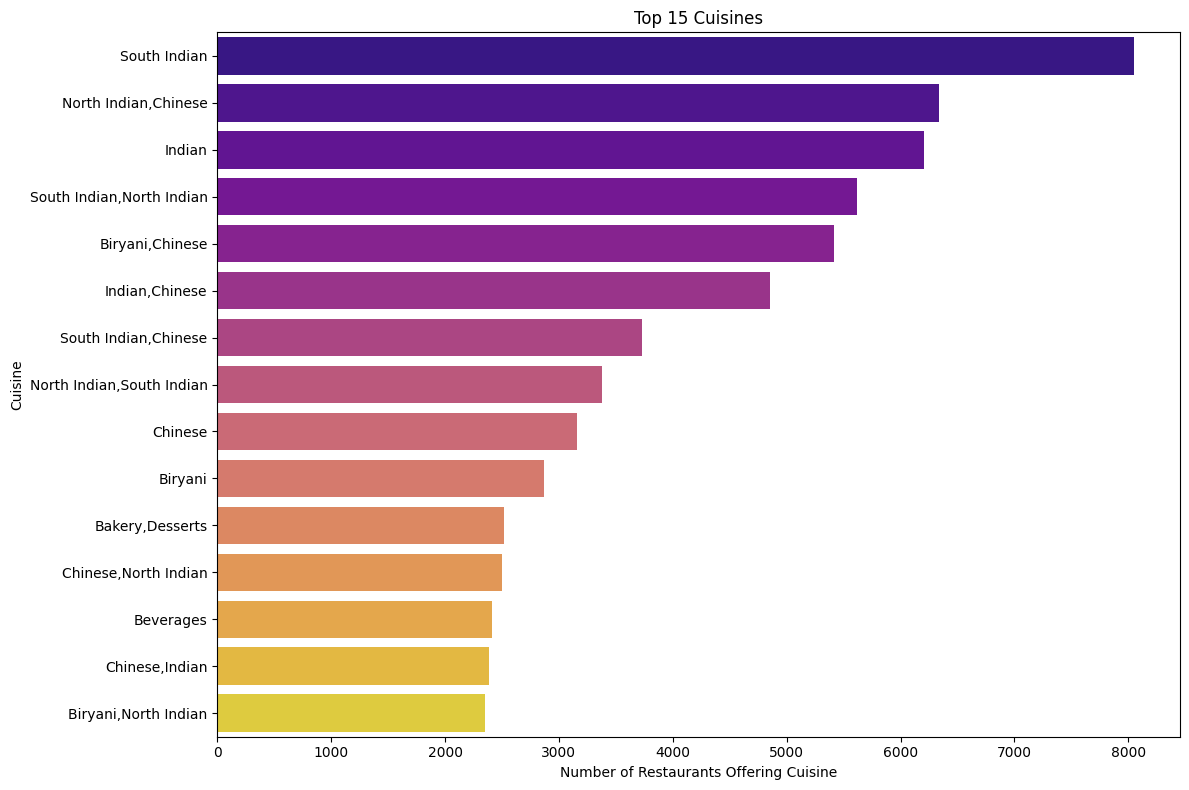

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the top 15 cuisines
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Cuisine', data=top_15_cuisines, palette='plasma')
plt.title('Top 15 Cuisines')
plt.xlabel('Number of Restaurants Offering Cuisine')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

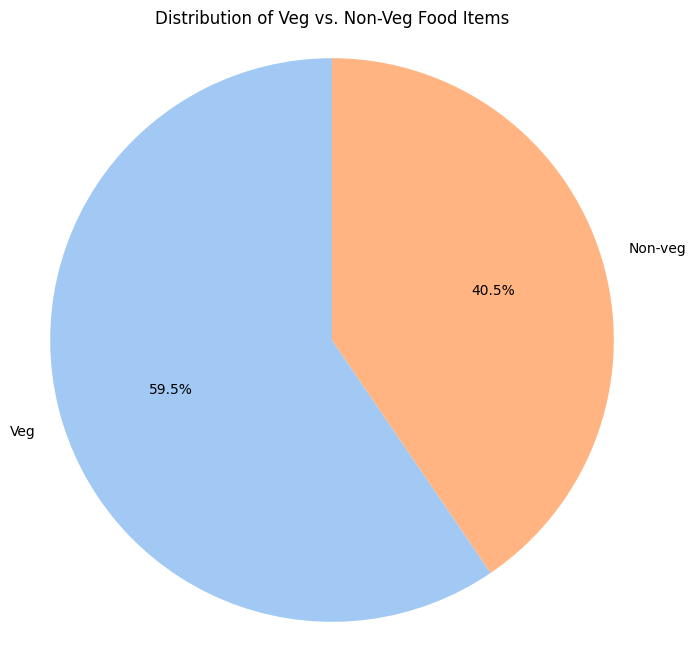

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get counts for 'Veg' and 'Non-Veg' items
veg_nonveg_counts = swiggy_analysis['Veg_or_Non_Veg'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(veg_nonveg_counts, labels=veg_nonveg_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Veg vs. Non-Veg Food Items')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Note on Price Comparison

I am unable to provide an average price comparison between 'Veg' and 'Non-Veg' items because the `Price` column was removed from the `swiggy_analysis` DataFrame earlier in the analysis. If you wish to perform this comparison, the dataset would need to be reloaded with the `Price` column intact.

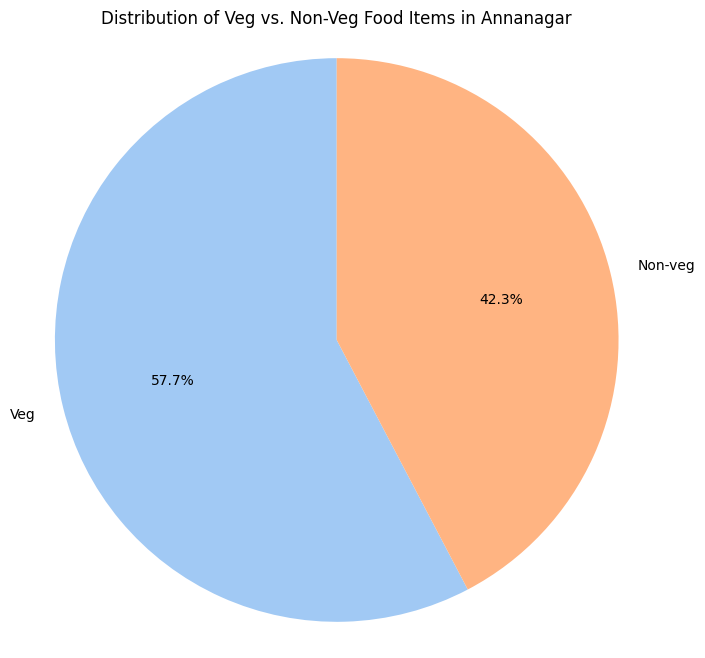

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for Annanagar subcity
annanagar_data = swiggy_analysis[swiggy_analysis['Sub_City'] == 'Annanagar']

# Get counts for 'Veg' and 'Non-Veg' items in Annanagar
annanagar_veg_nonveg_counts = annanagar_data['Veg_or_Non_Veg'].value_counts()

# Create a pie chart for Annanagar
plt.figure(figsize=(8, 8))
plt.pie(annanagar_veg_nonveg_counts, labels=annanagar_veg_nonveg_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Veg vs. Non-Veg Food Items in Annanagar')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Note on Price Comparison for Annanagar

As mentioned previously, I am unable to provide an average price comparison between 'Veg' and 'Non-Veg' items, even for the specific 'Annanagar' subcity, because the `Price` column was removed from the `swiggy_analysis` DataFrame. If price analysis is crucial, the dataset would need to be reloaded with the `Price` column intact before any cleaning steps that remove it.

In [ ]:
# Filter restaurants with at least 100 ratings
restaurants_with_enough_ratings = swiggy_analysis[swiggy_analysis['Rating_Count'] >= 100]

# Group by restaurant and calculate the mean rating (in case of duplicate entries for a restaurant)
# Then sort by rating in descending order and get the top 10
top_10_rated_restaurants = restaurants_with_enough_ratings.groupby('Restaurant')['Rating'].mean().sort_values(ascending=False).head(10).reset_index()

print("Top 10 Rated Restaurants (with min 100 ratings):")
# Check if the DataFrame is empty
if top_10_rated_restaurants.empty:
    print("No restaurants found with at least 100 ratings.")
else:
    print(top_10_rated_restaurants)

    # Optionally, visualize this
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Rating', y='Restaurant', data=top_10_rated_restaurants, palette='viridis')
    plt.title('Top 10 Rated Restaurants (Min 100 Ratings)')
    plt.xlabel('Average Rating')
    plt.ylabel('Restaurant Name')
    # Adjust x-axis limits for better visualization of ratings, ensure there's data to plot
    plt.xlim(top_10_rated_restaurants['Rating'].min() - 0.1, 5.0)
    plt.tight_layout()
    plt.show()

Top 10 Rated Restaurants (with min 100 ratings):
No restaurants found with at least 100 ratings.


Top 10 Rated Restaurants (with min 4+ rating):
                             Restaurant  Rating
0     Not Just A Cake by Jayaa Kennethh     5.0
1                            Spice Nyce     4.9
2                     NI FOODS AND DIET     4.9
3                AMUL ICE CREAM PARLOUR     4.9
4                 THE LEAN BEAN CHENNAI     4.9
5                   Mcrennett ( Parrys)     4.8
6  Fabelle Chocolates - ITC Grand Chola     4.8
7                         Hotel Kumaran     4.8
8                       Freshlings Cafe     4.8
9        TEA TIME -KUTCHERY ROAD BRANCH     4.7


/tmp/ipykernel_6322/3736514791.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rating', y='Restaurant', data=top_10_rated_restaurants_4plus, palette='viridis')


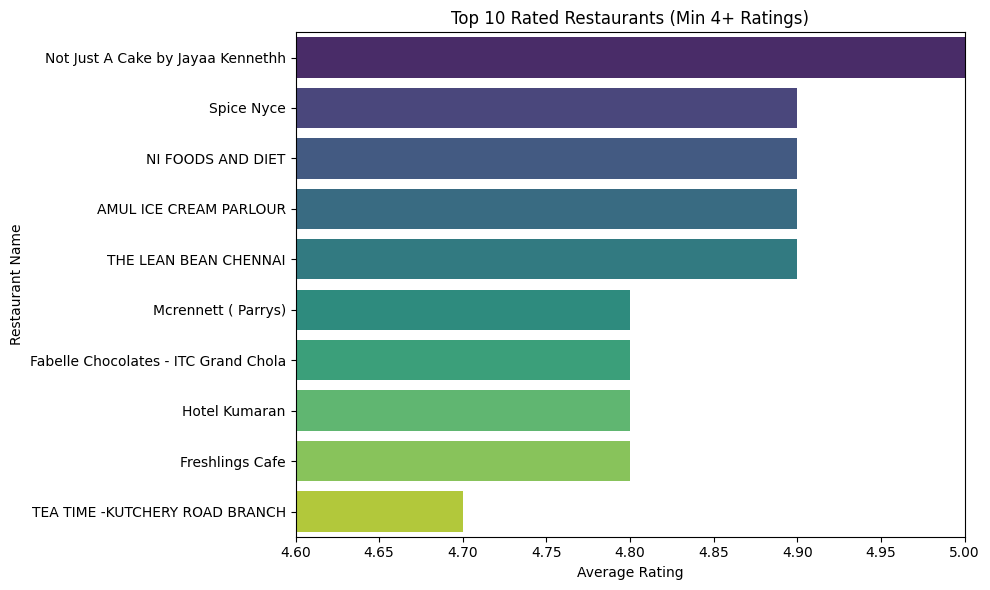

In [ ]:
# Filter restaurants with a minimum rating of 4.0
restaurants_with_min_4_rating = swiggy_analysis[swiggy_analysis['Rating'] >= 4.0]

# Group by restaurant and calculate the mean rating
# Then sort by rating in descending order and get the top 10
top_10_rated_restaurants_4plus = restaurants_with_min_4_rating.groupby('Restaurant')['Rating'].mean().sort_values(ascending=False).head(10).reset_index()

print("Top 10 Rated Restaurants (with min 4+ rating):")
# Check if the DataFrame is empty
if top_10_rated_restaurants_4plus.empty:
    print("No restaurants found with at least a 4+ rating.")
else:
    print(top_10_rated_restaurants_4plus)

    # Visualize this
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Rating', y='Restaurant', data=top_10_rated_restaurants_4plus, palette='viridis')
    plt.title('Top 10 Rated Restaurants (Min 4+ Ratings)')
    plt.xlabel('Average Rating')
    plt.ylabel('Restaurant Name')
    # Adjust x-axis limits for better visualization of ratings
    plt.xlim(top_10_rated_restaurants_4plus['Rating'].min() - 0.1, 5.0)
    plt.tight_layout()
    plt.show()

### Summary Insights

Based on our exploratory data analysis of the Swiggy Chennai dataset, here are some key statistics and findings:

*   **Total Entries**: The dataset contains 162,520 entries.
*   **Subcity with Most Restaurants**: `Annanagar` emerged as the subcity with the highest number of restaurants, hosting **8,236** establishments.
*   **Most Popular Cuisine**: `South Indian` is the most frequently offered cuisine, appearing **8,051** times in the dataset. Closely followed by `North Indian,Chinese` with **6,341** occurrences.
*   **Veg vs. Non-Veg Food Items**: The distribution of food items indicates a higher prevalence of vegetarian options:
    *   **Veg**: 96,729 items
    *   **Non-Veg**: 65,791 items
*   **Top Rated Restaurants (Minimum 4+ Rating)**: The analysis revealed several highly-rated restaurants. The top restaurant identified was `Not Just A Cake by Jayaa Kennethh` with an average rating of **5.0**.
*   **Cost Segmentation**: Restaurants were segmented into cost buckets, revealing the following distribution:
    *   **Mid-range**: 73,472 restaurants
    *   **Premium**: 61,151 restaurants
    *   **Luxury**: 21,169 restaurants
    *   **Budget**: 6,728 restaurants

These insights provide a foundational understanding of the restaurant landscape in Chennai as represented by this Swiggy dataset.

count    162520.000000
mean        311.845416
std         180.921978
min          30.000000
25%         200.000000
50%         300.000000
75%         350.000000
max        2500.000000
Name: Cost, dtype: float64
0.25    200.0
0.50    300.0
0.75    350.0
0.90    500.0
Name: Cost, dtype: float64


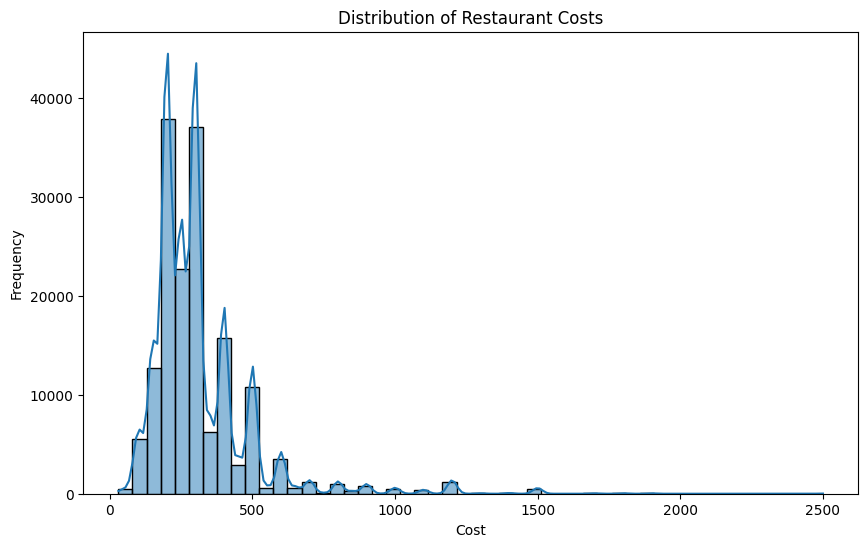

In [ ]:
print(swiggy_analysis['Cost'].describe())
print(swiggy_analysis['Cost'].quantile([0.25, 0.5, 0.75, 0.9]))

plt.figure(figsize=(10, 6))
sns.histplot(swiggy_analysis['Cost'], bins=50, kde=True)
plt.title('Distribution of Restaurant Costs')
plt.xlabel('Cost')
plt.ylabel('Frequency')
plt.show()

Cost Segmentation Counts:
Cost_Bucket
Mid-range    73472
Premium      61151
Luxury       21169
Budget        6728
Name: count, dtype: int64


/tmp/ipykernel_6322/3661750928.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cost_Bucket', data=swiggy_analysis, order=labels, palette='viridis')


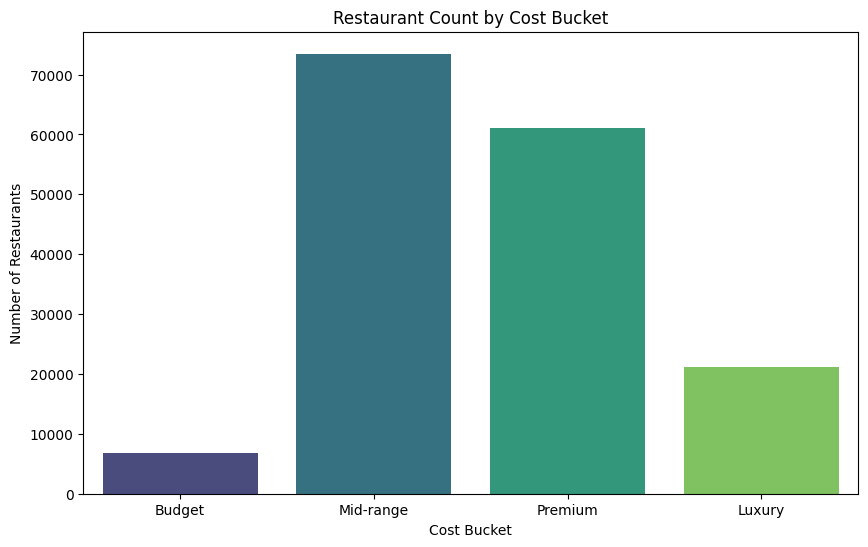

In [ ]:
# Define cost ranges based on the distribution (these can be adjusted)
# Example ranges, adjust after inspecting the distribution above
bins = [0, 150, 300, 500, swiggy_analysis['Cost'].max() + 1]
labels = ['Budget', 'Mid-range', 'Premium', 'Luxury']

swiggy_analysis['Cost_Bucket'] = pd.cut(swiggy_analysis['Cost'], bins=bins, labels=labels, right=False)

print("Cost Segmentation Counts:")
print(swiggy_analysis['Cost_Bucket'].value_counts())

# Visualize the cost segmentation
plt.figure(figsize=(10, 6))
sns.countplot(x='Cost_Bucket', data=swiggy_analysis, order=labels, palette='viridis')
plt.title('Restaurant Count by Cost Bucket')
plt.xlabel('Cost Bucket')
plt.ylabel('Number of Restaurants')
plt.show()

In [ ]:
output_filename = 'swiggy_analysis_manipulated.csv'
swiggy_analysis.to_csv(output_filename, index=False)
print(f"DataFrame successfully exported to '{output_filename}' in the current directory.")

DataFrame successfully exported to 'swiggy_analysis_manipulated.csv' in the current directory.
